In [16]:
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import pandas as pd
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import time
import requests
import numpy as np

In [18]:
def get_agro_data(parsing_type : str = 'static' ): 
    
    """
    Функция для получения данных о цене на корм с сайта https://www.agrosadovod.ru.
    Принимает на вход тип парсинга: static или dynamic
    """
    
    assert parsing_type in ['static', 'dynamic'], f'{parsing_type} не поддерживатеся. Выберите static или dynamic'
    names = []
    prices = []
    
    if parsing_type == 'dynamic':
        driver = webdriver.Chrome()
        actions = ActionChains(driver)       
        for page in range(1, 8): # 
            driver.get(f"https://www.agrosadovod.ru/catalog/korma-dlya-ptits/kury/nesushek/page/{page}/")
            time.sleep(1.5)
            actions.send_keys(Keys.END).perform()
            time.sleep(1.5)
            names_list = driver.find_elements(By.CLASS_NAME, "product-loop-title")
            price_list = driver.find_elements(By.CLASS_NAME, "price")
            names += [name.text for name in names_list] # сохраняем названия кормов
            prices += [int(price.text.split()[-2]) for price in price_list] # сохраняем цены кормов
        driver.quit()
        
    else:
        for page in range(1, 8):
            html = requests.get(f"https://www.agrosadovod.ru/catalog/korma-dlya-ptits/kury/nesushek/page/{page}/").text
            soup = BeautifulSoup(html, 'lxml')
            goods_list = soup.findAll('a', class_ = 'product-loop-title')
            prices_list = soup.findAll('span', class_ = 'price')
            names += [good.text for good in goods_list] # сохраняем названия кормов
            prices += [int(price.findAll(class_ = "woocommerce-Price-amount amount")[-1].text.split()[0]) for price in prices_list] # сохраняем цены кормов
    
    d = dict(zip(names, prices))
    keys = []
    
    for name in d:
        if any(st in name.upper() for st in ["СМЕСЬ", "КОМБИКОРМ"]): # мы будем давать курочкам именно готовые, здоровые смеси и комбикорма
            keys.append(name)
            
    df_agro = pd.DataFrame({"Название" : keys, "Цена" : [d[key] for key in keys]})
    df_agro['КГ в мешке'] = df_agro['Название'].str.extract(r'(\d+) [Кк][Гг]') # из названия достаем кол-во кг в упаковке
    df_agro['КГ в мешке'] = pd.to_numeric(df_agro['КГ в мешке'])
    df_agro.dropna(inplace = True)
    df_agro["Цена за КГ"] = df_agro["Цена"] / df_agro["КГ в мешке"]
    df_agro['Магазин'] = 'Агросадовод'
    
    return df_agro


In [20]:
def get_ozon_data():
    
    """
    Функция для получения данных о цене на корм с озона
    """
    
    options = webdriver.ChromeOptions()
    # подгружаем UserAgent своего браузера, чтобы обойти защиту Ozon от ботов
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36")
    # подгружаем профиль своего браузера, чтобы обойти защиту Ozon от ботов
    options.add_argument(r"user-data-dir=C:\Users\Yaroslav\AppData\Local\Google\Chrome\User Data")  
    options.add_argument('--profile-directory=Default')
    driver = webdriver.Chrome(options=options)
    actions = ActionChains(driver)
    prices = []
    names = []
    
    for i in range(10): # парсим первые 10 страниц
        url = f'https://www.ozon.ru/category/kombikorm-dlya-kur-nesushek/?page={1+4*i}&search_page_state=fDTeLRzirH_QScT9xHj04E-mPR822Or9HsRbpPNYt4yNMFH13pr6hyUrjoDLEES9s06f8rEN_8oQNI-8VZeOj60JuuKoog3v-xadvP1ncPFQwTEATdFvBLzEtL3LvP1WdHXqyrb5O1eNCvwrmku6U22fnhDQmlI22EJqcIrn-5JmgwMsSTkaWNCk5j4gNJ5Qmqu38_PYSX027K-RDp69C-OlDPPGQFjz4tQ3HPW-Uyk-k342t77g-rEyEWGGGG5F9mBd9w5w30twT7s0_T_5UQr2IkHBtidJDOCKpfn48V5k3VaaRSrRKav67fFwREf_MZey_xJhhIBqfHngM3mkTBRKBiAK6dvHi-kxXMXl2ZjHZ4G7g7R3Fs2rDxsGBpHmnkJKRdOvUeMT4W2kD6GT7sNOwrzRZg%3D%3D'
        driver.get(url)
        time.sleep(3)
        actions.send_keys(Keys.END).perform()
        time.sleep(3)
        actions.send_keys(Keys.END).perform()
        time.sleep(3)
        actions.send_keys(Keys.END).perform()
        goods = driver.find_elements(By.CLASS_NAME, "jm2_25.m2j_25.tile-root")
        nms = [good.find_element(By.CLASS_NAME, "tsBody500Medium") for good in goods]
        prcs = [int(''.join(good.find_element(By.CLASS_NAME, "c3025-a1.tsHeadline500Medium.c3025-b1.c3025-a6").text.split()[:-1])) for good in goods]
        names += [name.text for name in nms]
        prices += prcs
        
    d = dict(zip(names, prices))
    stop_words = ['добавк', 'витамин']
    cont_words = ['комбикорм', 'смес']
    names_to_save = []
    
    for name in d:
        # извлекаем только корма, не добавки и не витамины
        if any(st in name.lower() for st in cont_words) and not any(st in name.lower() for st in stop_words) and ('кг' in name.lower()):
            names_to_save.append(name)
            
    df_ozon = pd.DataFrame({"Название" : names_to_save, "Цена" : [d[key] for key in names_to_save]})
    df_ozon['КГ в мешке'] = df_ozon['Название'].str.extract(r'(\d+)\s*[КкКк][Гг]')
    df_ozon['КГ в мешке'] = pd.to_numeric(df_ozon['КГ в мешке'])
    df_ozon['Цена за КГ'] = df_ozon['Цена'] / df_ozon['КГ в мешке']
    df_ozon['Магазин'] = 'Озон'
    driver.quit()
    
    return df_ozon

In [22]:
def get_nutrition_price(): 
    """
    Получаем среднюю цену из 10 самых дешевых предложений 
    на рынке
    """
    df_agro = get_agro_data('static')
    df_ozon = get_ozon_data()
    df = pd.concat([df_agro, df_ozon], ignore_index = True)
    df = df.sort_values(by='Цена за КГ')
    df = df.reset_index(drop = True)
    print(np.mean(df.loc[:10, "Цена за КГ"]))

In [24]:
df_agro = get_agro_data('static')
df_ozon = get_ozon_data()

In [25]:
df = pd.concat([df_agro, df_ozon], ignore_index = True)
df = df.sort_values(by='Цена за КГ')
df = df.reset_index(drop = True)

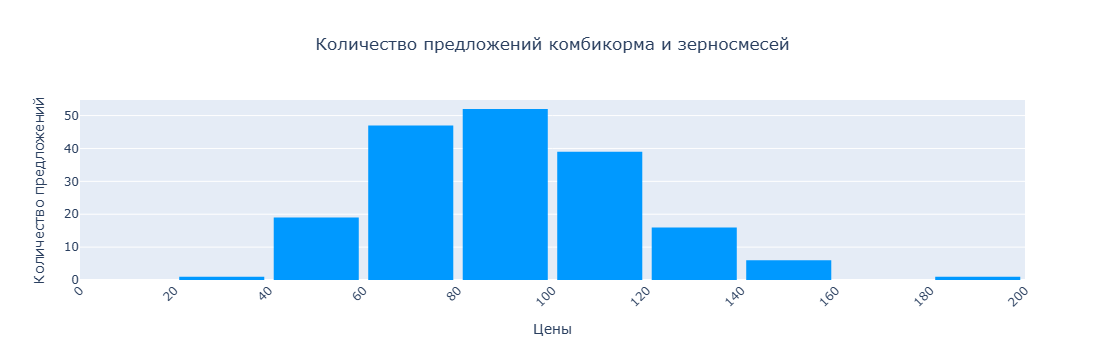

In [30]:
import pandas as pd
import plotly.express as px

fig = px.histogram(df, x="Цена за КГ", nbins=10, title="Количество предложений комбикорма и зерносмесей", color_discrete_sequence=['#0099ff', '#09bfe8', '#17fff9'])
fig.update_layout(
    xaxis_title="Диапазон цен",
    yaxis_title="Количество предложений",
    bargap=0.1,
    width = 800,
    title_x = 0.5
)
fig.update_xaxes(dtick=20, tickangle=-45, title='Цены', range = [0, 200])
fig.show()

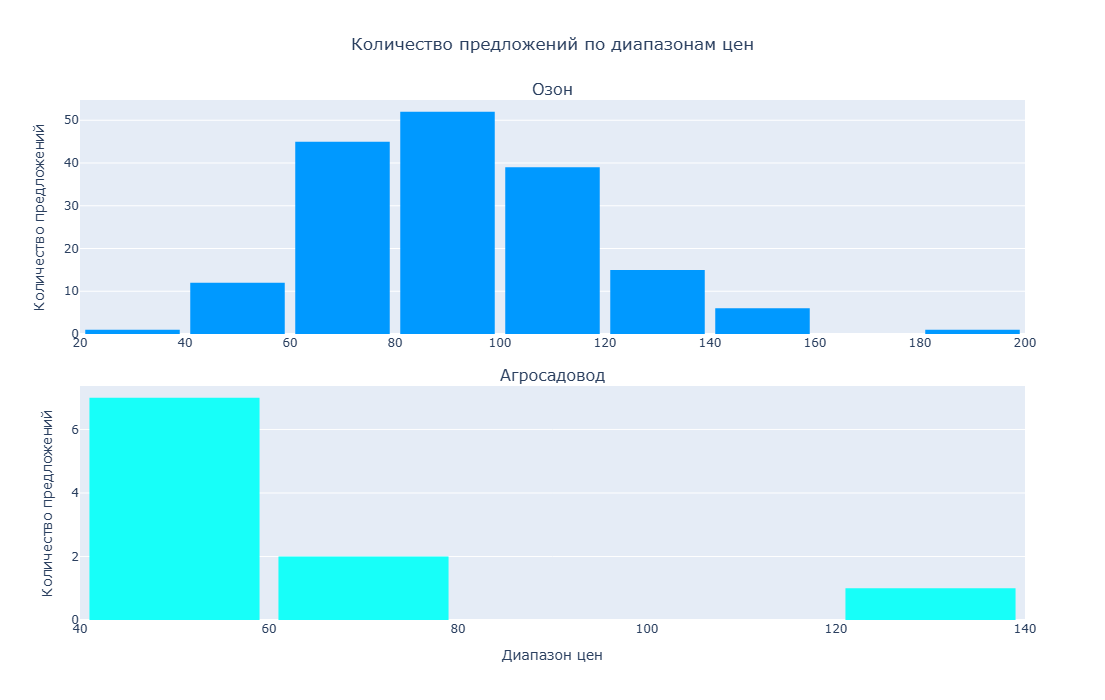

In [27]:
from plotly.subplots import make_subplots

fig_ozon = px.histogram(df_ozon, x="Цена за КГ", nbins=10, title="Озон", color_discrete_sequence=['#0099ff'])
fig_agro = px.histogram(df_agro, x="Цена за КГ", nbins=10, title="Агросадовод", color_discrete_sequence=['#17fff9'])

fig = make_subplots(rows=2, cols=1, subplot_titles=("Озон", "Агросадовод"), vertical_spacing=0.1)

fig.add_trace(fig_ozon.data[0], row=1, col=1)
fig.add_trace(fig_agro.data[0], row=2, col=1)

fig.update_layout(
    title_text="Количество предложений по диапазонам цен",
    xaxis_title="Диапазон цен",
    yaxis_title="Количество предложений",
    bargap=0.1,
    height = 700,
    width = 700,
    title_x = 0.5
)

fig.update_xaxes(title_text="", row=1, col=1)
fig.update_xaxes(title_text="Диапазон цен", row=2, col=1)
fig.update_yaxes(title_text="Количество предложений", row=2, col=1)

fig.show()

In [28]:
# Задел на будущее для цифрового двойника, расходы на корм в месяц
def nutrition_costs(chickens):
    gramms = 0 # сколько всем нашим курам нужно корма в день
    
    for chicken in chickens:
        if chicken.age <= 1/6:
            gramms += 50
        elif chicken.age <= 1/3:
            gramms += 100
        else:
            gramms += 130
    return gramms * 30 * get_nutrition_price()